# V1 — Portefeuille par congressman → classement par IR

**But.** Reconstruire le portefeuille réel de chaque membre (ses achats/ventes), en faire une courbe, et classer les membres par leur capacité à **battre le SPY**.

**Méthode.** Rendement *time-weighted* (un apport n'est jamais un rendement). Pondération par l'argent (value-weight). Actions seules. Entrée à la date de transaction (`traded`).

**On s'arrête au classement par IR.** (Éligibilité, significativité, portefeuille top-4, version suivable = plus tard.)

## 0. Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt

BASE = "/Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours"
PRICES = os.path.join(BASE, "cache", "prices")

## 1. Charger les trades
Source unique : la table 2014-2026.

In [2]:
df = pd.read_csv(os.path.join(BASE, "table_congres_2014_2026.csv"), low_memory=False)
df.shape

(138557, 22)

In [3]:
df[["name", "ticker", "op", "traded", "size_usd", "ticker_type"]].head()

,name,ticker,op,traded,size_usd,ticker_type
0,Greg Gianforte,LKQ,sell,2019-12-24,100001.0,ST
1,Bob Gibbs,T,buy,2019-12-23,1001.0,ST
2,Thomas Macarthur,IBKR,buy,2019-12-21,1001.0,ST
3,Greg Gianforte,BCS,buy,2019-12-21,15001.0,ST
4,Bob Gibbs,MRO,sell,2019-12-19,1001.0,ST


## 2. Filtrer : actions, achats/ventes, dates propres

- garder `op ∈ {buy, sell}`
- garder les actions : `ticker_type ∈ {Stock, ST}`
- ticker non vide
- dates `traded` valides (2013-2026 ; on jette les aberrantes type `3031`)
- `size_usd` = **borne basse** de la fourchette \$ → sert de montant investi

In [4]:
n0 = len(df)
df = df[df["op"].isin(["buy", "sell"])]
df = df[df["ticker_type"].isin(["Stock", "ST"])]
df = df[df["ticker"].notna()]
df["traded"] = pd.to_datetime(df["traded"], errors="coerce")
df = df[df["traded"].notna()]
df = df[(df["traded"].dt.year >= 2013) & (df["traded"].dt.year <= 2026)]
df = df[df["size_usd"].notna() & (df["size_usd"] > 0)]
df = df[["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]].reset_index(drop=True)
print(f"{n0} -> {len(df)} trades  |  {df['bioguide_id'].nunique()} membres  |  {df['ticker'].nunique()} tickers")

138557 -> 80694 trades  |  304 membres  |  3550 tickers


In [5]:
df.head()

,bioguide_id,name,ticker,op,traded,size_usd
0,G000584,Greg Gianforte,LKQ,sell,2019-12-24,100001.0
1,G000563,Bob Gibbs,T,buy,2019-12-23,1001.0
2,M001193,Thomas Macarthur,IBKR,buy,2019-12-21,1001.0
3,G000584,Greg Gianforte,BCS,buy,2019-12-21,15001.0
4,G000563,Bob Gibbs,MRO,sell,2019-12-19,1001.0


## 3. Prix (cache) + SPY
Le SPY donne le **calendrier de bourse maître**. On ne garde que les tickers présents dans le cache.

In [6]:
# SPY = benchmark ; son index = calendrier maître
spy = (pd.read_csv(os.path.join(PRICES, "SPY.csv"), parse_dates=["Date"])
         .set_index("Date")["close"].sort_index())
cal = spy.index
r_spy = spy.pct_change()          # rendement quotidien du marché
spy.tail(2)

Date
2026-06-24    733.239990
2026-06-25    734.299988
Name: close, dtype: float64

In [7]:
# charger le prix de chaque ticker utile, aligné sur le calendrier maître
have = {os.path.splitext(os.path.basename(p))[0] for p in glob.glob(os.path.join(PRICES, "*.csv"))}
need = sorted(set(df["ticker"]) & have)
missing = sorted(set(df["ticker"]) - have)

prices = {}
for tk in need:
    s = (pd.read_csv(os.path.join(PRICES, tk + ".csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index())
    prices[tk] = s.reindex(cal).ffill()          # aligne + comble les petits trous

n_drop = df[~df["ticker"].isin(need)].shape[0]
df = df[df["ticker"].isin(need)].reset_index(drop=True)
print(f"tickers avec prix : {len(need)}  |  sans prix : {len(missing)}  |  trades jetes : {n_drop}")

tickers avec prix : 1850  |  sans prix : 1700  |  trades jetes : 9354


## 4. Parts détenues chaque jour — `member_shares`

Pour un membre :
1. chaque achat → `parts = size_usd / prix(1er jour ≥ traded)`
2. chaque vente → `parts_vendues = min(size_usd / prix, parts détenues)` *(pas de short)*
3. `N` = parts détenues par jour, **une colonne par ticker**

In [8]:
def eff_price(tk, d):
    # prix du 1er jour de bourse >= d (on transige au marche)
    s = prices[tk]; pos = s.index.searchsorted(d)
    if pos >= len(s): return None, None
    p = s.iloc[pos]
    if not np.isfinite(p) or p <= 0: return None, None
    return s.index[pos], p

In [9]:
def member_shares(g):
    # g = trades d'un membre  ->  N (parts detenues par jour, colonnes = tickers)
    cols = {}
    for tk, gt in g.groupby("ticker"):
        h, events = 0.0, {}
        for _, row in gt.sort_values("traded").iterrows():
            dd, p = eff_price(tk, row["traded"])
            if dd is None:
                continue
            qty = row["size_usd"] / p
            h = h + qty if row["op"] == "buy" else h - min(qty, h)   # pas de short
            events[dd] = h
        if events:
            cols[tk] = pd.Series(events).sort_index().reindex(cal).ffill().fillna(0.0)
    return pd.DataFrame(cols) if cols else None

**Démo** sur un membre. À changer via `MEMBRE`.

In [10]:
MEMBRE = "John Fetterman"
g = df[df["name"] == MEMBRE]
Nm = member_shares(g)
g[["ticker", "op", "traded", "size_usd"]]

,ticker,op,traded,size_usd
67717,GOOG,buy,2025-05-15,1001.0
67718,JPM,buy,2025-06-17,1001.0
69241,JPM,buy,2025-06-17,1001.0
69242,ERIE,buy,2026-03-27,1001.0
69243,MSFT,buy,2026-03-27,1001.0
69244,T,sell,2026-03-27,1001.0
69245,MSFT,buy,2026-03-30,1001.0
69246,AMZN,buy,2026-03-30,1001.0
69247,GOOG,buy,2026-03-30,1001.0
69248,ERIE,buy,2026-03-30,1001.0


Le tableau `N` : parts détenues par jour. Monte à l'achat, baisse à la vente.

In [11]:
actifs = Nm[Nm.sum(axis=1) > 0]
actifs.iloc[::max(1, len(actifs) // 12)].round(1)      # apercu

,AMZN,ERIE,GOOG,JPM,MSFT,MU,T
Date,,,,,,,
2025-05-15,0.0,0.0,6.1,0.0,0.0,0.0,0.0
2025-06-18,0.0,0.0,6.1,7.6,0.0,0.0,0.0
2025-07-23,0.0,0.0,6.1,7.6,0.0,0.0,0.0
2025-08-25,0.0,0.0,6.1,7.6,0.0,0.0,0.0
2025-09-26,0.0,0.0,6.1,7.6,0.0,0.0,0.0
2025-10-29,0.0,0.0,6.1,7.6,0.0,0.0,0.0
2025-12-02,0.0,0.0,6.1,7.6,0.0,0.0,0.0
2026-01-06,0.0,0.0,6.1,7.6,0.0,0.0,0.0
2026-02-09,0.0,0.0,6.1,7.6,0.0,0.0,0.0


## 5. Rendement quotidien — `daily_return`

`r^P(t) = [Σ nᵢ(t−1)·Pᵢ(t)] / [Σ nᵢ(t−1)·Pᵢ(t−1)] − 1`

On valorise les parts **de la veille** (`shift(1)`) → un apport n'est jamais un rendement. Jour sans position → `0` (cash).

In [12]:
def daily_return(N):
    P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    Nsh = N.shift(1)                                    # parts de la veille
    num = (Nsh * P).sum(axis=1)                         # Sum n_i(t-1) * P_i(t)
    den = (Nsh * P.shift(1)).sum(axis=1)                # Sum n_i(t-1) * P_i(t-1)
    r = pd.Series(np.where(den > 0, num / den - 1.0, 0.0), index=N.index)
    active = N.sum(axis=1) > 0
    if not active.any():
        return pd.Series(dtype=float)
    return r.loc[active.idxmax(): active[::-1].idxmax()]   # 1re -> derniere position

In [13]:
rm = daily_return(Nm)
rm.describe()

count    279.000000
mean       0.002187
std        0.012474
min       -0.032537
25%       -0.005350
50%        0.002142
75%        0.010679
max        0.035809
dtype: float64

## 6. Stats d'un portefeuille — `stats`

`NAV = Π(1+r)` · `CAGR = NAV_T^(252/T) − 1` · `vol = σ(r)·√252` · `Sharpe = mean(r)/σ(r)·√252` · `maxDD`

In [14]:
def stats(r):
    nav = (1 + r).cumprod(); T = len(r)
    cagr = nav.iloc[-1] ** (252 / T) - 1 if nav.iloc[-1] > 0 else np.nan
    return dict(cagr=cagr,
                vol=r.std() * np.sqrt(252),
                sharpe=r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan,
                maxdd=(nav / nav.cummax() - 1).min())

In [15]:
stats(rm)

{'cagr': np.float64(0.7007162802713041),
 'vol': np.float64(0.1980168105089696),
 'sharpe': np.float64(2.7831165431645553),
 'maxdd': np.float64(-0.15278720850768124)}

### Visuel : le portefeuille du membre vs le SPY (base 100)

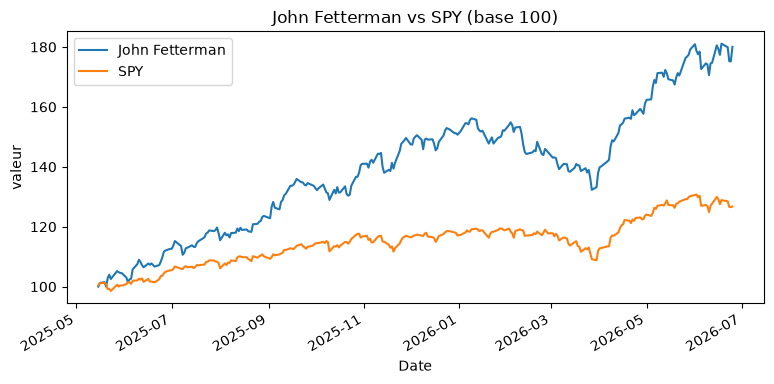

In [16]:
nav_m = (1 + rm).cumprod()
nav_s = (1 + r_spy.reindex(rm.index).fillna(0)).cumprod()
ax = (100 * nav_m).plot(label=MEMBRE, figsize=(9, 4))
(100 * nav_s).plot(ax=ax, label="SPY")
ax.set_title(f"{MEMBRE} vs SPY (base 100)"); ax.set_ylabel("valeur"); ax.legend(); plt.show()

## 7. Battre le SPY — l'Information Ratio

`x(t) = r^P(t) − r_SPY(t)` puis `IR = mean(x) / σ(x) · √252`

IR > 0 → il bat le SPY. Plus c'est grand, plus l'avance est **régulière**. **C'est le critère de classement.**

In [17]:
def info_ratio(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

In [18]:
info_ratio(rm)

np.float64(2.343060572347207)

## 8. Classer TOUS les membres par IR
Une ligne par membre, triée par IR décroissant.

In [19]:
rows = []
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    s = stats(r)
    rows.append(dict(name=g["name"].iloc[0], n_trades=len(g),
                     IR=info_ratio(r), sharpe=s["sharpe"],
                     cagr=s["cagr"], vol=s["vol"], maxdd=s["maxdd"]))

tab = pd.DataFrame(rows).sort_values("IR", ascending=False).reset_index(drop=True)
print(len(tab), "membres classes")

213 membres classes


### Top 20

In [20]:
tab.head(20).round(3)

,name,n_trades,IR,sharpe,cagr,vol,maxdd
0,John Fetterman,11,2.343,2.783,0.701,0.198,-0.153
1,Ashley Moody,21,2.017,1.892,1.054,0.429,-0.339
2,Greg Steube,1,1.855,2.063,4.091,1.044,-0.298
3,Lisa McClain,1347,1.558,1.626,0.771,0.401,-0.342
4,Julia Letlow,214,1.550,1.452,0.317,0.204,-0.217
5,Morgan McGarvey,26,1.457,1.669,0.590,0.306,-0.284
6,Bruce Westerman,192,1.272,1.518,0.410,0.247,-0.169
7,David Kustoff,2,1.173,1.285,0.580,0.426,-0.371
8,Suzan K. Delbene,36,1.149,1.263,0.402,0.305,-0.280
9,Jon Kyl,7,1.108,1.164,0.448,0.381,-0.485


### Visuel : top 20 par IR

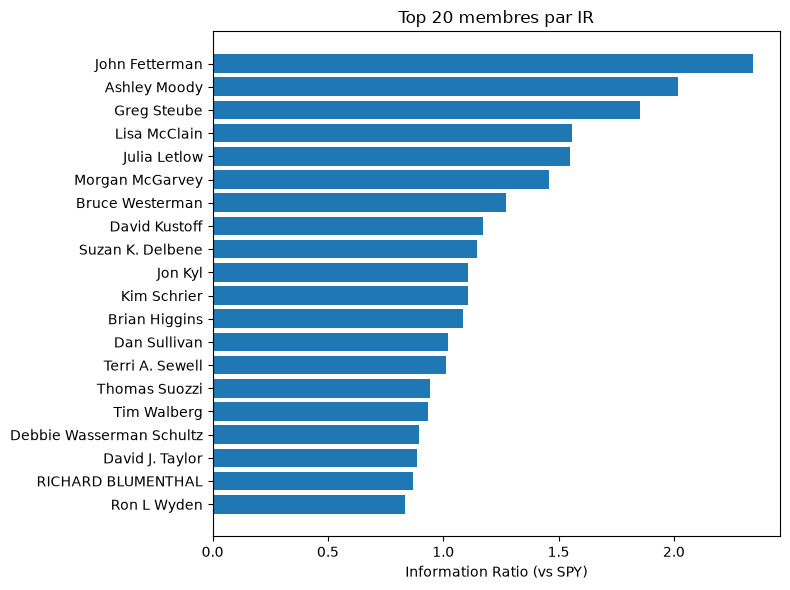

In [21]:
top = tab.head(20).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top["name"], top["IR"])
plt.xlabel("Information Ratio (vs SPY)")
plt.title("Top 20 membres par IR")
plt.tight_layout(); plt.show()

## Fin

On s'arrête au **classement par IR**, comme prévu.

Prochaines étapes (plus tard) : filtre d'éligibilité (≥ N trades), significativité (DSR), portefeuille **top-4** vs SPY, puis version **suivable** (`filed` + walk-forward).